## Monireh Eshghinezhad
## MAI1202 — Assignment #1 - Deep Neural Networks vs Traditional ML
### Task: Regression — predict house price

# Data Preparation

In [42]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load the dataset
df = pd.read_csv('kc_house_data.csv')

Using device: cuda


In [43]:
# Exploratory checks
print(f'Dataset shape: {df.shape}')
# Check for missing values
print('Dtypes & non-null counts:')
print(df.info())

print('\nFirst 5 rows:')
print(df.head())

print('\nBasic statistics:')
df.describe()

Dataset shape: (21613, 21)
Dtypes & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 1

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


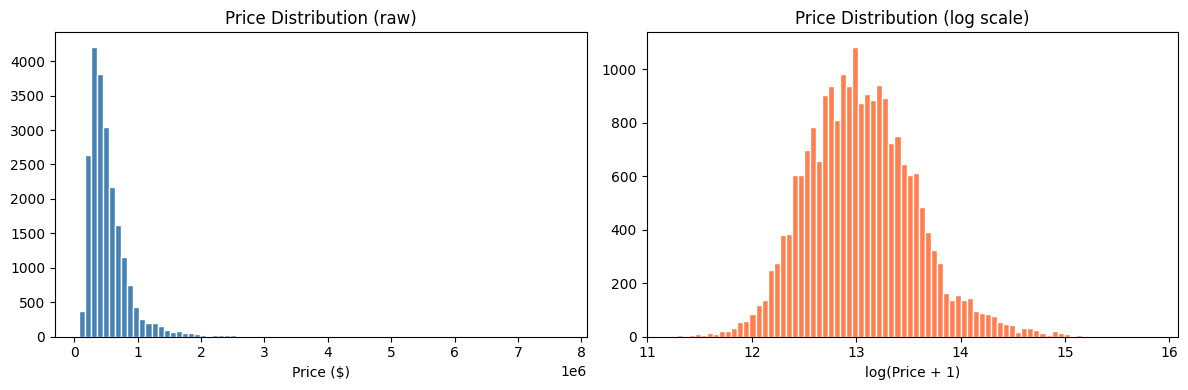

In [44]:
# Visualise the target variable (price)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price ($)')

# Prices are heavily right-skewed (a few very expensive mansions).  A log
# transform makes the distribution more bell-shaped and helps models learn.
axes[1].hist(np.log1p(df['price']), bins=80, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (log scale)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

# Feature engineering

In [45]:
# Parse the date column and extract year and month of sale
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['sale_year']  = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# Drop columns that are not useful as raw features
# zip codes look like numbers but they are really labels. Treating them as a number would mislead the model
drop_cols = ['id', 'date', 'zipcode']
df.drop(columns=drop_cols, inplace=True)

# Log-transform the target — models will predict log(price), then we exponentiate
# Taking the log makes the distribution more symmetric nd helps the neural network learn faster and more stably.
# We will convert predictions back to dollars at evaluation time.
df['log_price'] = np.log1p(df['price'])

print('Features after engineering:', df.shape)

# Feature Correlation with log(price)
corr = df.drop(columns=["price", "log_price"]).corrwith(df["log_price"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with log(price)")
ax.set_title("Feature Correlation with log(price)")
plt.tight_layout()
plt.show()

print(corr.sort_values(ascending=False).to_string())

Features after engineering: (21613, 21)


In [7]:
# Features and target value


# Train / Test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

In [8]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean/std FROM train, then apply
X_val   = scaler.transform(X_val)         # apply the SAME mean/std
X_test  = scaler.transform(X_test)